In [ ]:
!pip install kaggle --quiet

In [ ]:

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"petal2025","key":"c88a6e1381bcb3683557de000aaecce3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d lainguyn123/student-performance-factors
!kaggle datasets download -d eldarsarajlic/college-enrollment-in-the-us-20032021
!kaggle datasets download -d raymondtoo/the-world-university-rankings-2016-2024
!kaggle datasets download -d thedevastator/higher-education-predictors-of-student-retention
!kaggle datasets download -d jeromeblanchet/drivendatas-boxplots-for-education-dataset

Dataset URL: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
License(s): CC0-1.0
  0% 0.00/93.9k [00:00<?, ?B/s]
100% 93.9k/93.9k [00:00<00:00, 90.0MB/s]
Dataset URL: https://www.kaggle.com/datasets/eldarsarajlic/college-enrollment-in-the-us-20032021
License(s): unknown
  0% 0.00/819 [00:00<?, ?B/s]
100% 819/819 [00:00<00:00, 3.23MB/s]
Dataset URL: https://www.kaggle.com/datasets/raymondtoo/the-world-university-rankings-2016-2024
License(s): MIT
  0% 0.00/622k [00:00<?, ?B/s]
100% 622k/622k [00:00<00:00, 1.07GB/s]
Dataset URL: https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention
License(s): CC0-1.0
  0% 0.00/87.2k [00:00<?, ?B/s]
100% 87.2k/87.2k [00:00<00:00, 197MB/s]
Dataset URL: https://www.kaggle.com/datasets/jeromeblanchet/drivendatas-boxplots-for-education-dataset
License(s): unknown
  0% 0.00/20.7M [00:00<?, ?B/s]
100% 20.7M/20.7M [00:00<00:00, 1.29GB/s]


In [ ]:
!unzip -q student-performance-factors.zip -d student_performance
!unzip -q college-enrollment-in-the-us-20032021.zip -d college_enrollment
!unzip -q the-world-university-rankings-2016-2024.zip -d university_rankings
!unzip -q higher-education-predictors-of-student-retention.zip -d retention
!unzip -q drivendatas-boxplots-for-education-dataset.zip -d education

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()


In [ ]:
%matplotlib inline

In [1]:
"""
generic_accuracy_calculator_enhanced.py
======================================
- Fixes ColumnTransformer+TFIDF single-column Series issue via [tc] + flatten
- Provides preprocessing + baseline & tuned model training
- Returns rich metric dicts including timing + best params + best CV score
- NO LinearRegression anywhere (by design)
- Adds HistGradientBoosting (HistGB) for both regression & classification

NOTE: SHAP plotting + readiness scoring are handled in vertexML_enhanced.py.
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import time
from typing import Dict, Tuple, Any, List, Optional

from scipy import sparse

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier, HistGradientBoostingRegressor

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False


def detect_and_transform_wide_format(df: pd.DataFrame) -> Tuple[pd.DataFrame, bool]:
    year_cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 4]
    if len(year_cols) >= 5:
        id_cols = [c for c in df.columns if c not in year_cols]
        df_long = df.melt(id_vars=id_cols, value_vars=year_cols, var_name="Year", value_name="Value")
        df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
        df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
        return df_long, True
    return df, False


def detect_text_columns(df: pd.DataFrame, max_unique_ratio: float = 0.8) -> List[str]:
    text_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            sample = df[c].dropna().astype(str).head(300)
            if len(sample) == 0:
                continue
            avg_len = sample.map(len).mean()
            uniq_ratio = sample.nunique() / max(len(sample), 1)
            if avg_len >= 20 and uniq_ratio <= max_unique_ratio:
                text_cols.append(c)
    return text_cols


def detect_task_type(y: pd.Series, user_task_type: str = "auto") -> str:
    if user_task_type and str(user_task_type).lower() != "auto":
        return user_task_type
    if y.dtype == "object" or y.dtype.name == "category":
        return "Classification"
    nun = y.dropna().nunique()
    if pd.api.types.is_integer_dtype(y) and nun <= 20:
        return "Classification"
    return "Regression"


def build_preprocessor(
    X: pd.DataFrame,
    text_cols: List[str],
    use_tfidf: bool = True,
    max_tfidf_features: int = 10000
) -> ColumnTransformer:
    all_cols = list(X.columns)
    text_cols = [c for c in text_cols if c in all_cols]

    numeric_cols = [c for c in all_cols if pd.api.types.is_numeric_dtype(X[c]) and c not in text_cols]
    categorical_cols = [c for c in all_cols if (X[c].dtype == "object" or X[c].dtype.name == "category") and c not in text_cols]

    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False))
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    transformers = []
    if numeric_cols:
        transformers.append(("num", num_pipe, numeric_cols))
    if categorical_cols:
        transformers.append(("cat", cat_pipe, categorical_cols))

    if use_tfidf and text_cols:
        for tc in text_cols:
            text_pipe = Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("flatten", FunctionTransformer(lambda x: x.ravel().astype(str), validate=False)),
                ("tfidf", TfidfVectorizer(max_features=max_tfidf_features, stop_words="english"))
            ])
            transformers.append((f"tfidf_{tc}", text_pipe, [tc]))  # ✅ [tc] keeps it 2D

    return ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)


def preprocess_data(
    df: pd.DataFrame,
    target_column: str,
    task_type: str = "auto",
    feature_columns: Optional[List[str]] = None,
    use_tfidf: bool = True,
    max_tfidf_features: int = 10000,
    test_size: float = 0.2,
    random_state: int = 42
):
    if feature_columns is None:
        X = df.drop(columns=[target_column])
    else:
        X = df[feature_columns].copy()

    y = df[target_column].copy()
    task_type_final = detect_task_type(y, user_task_type=task_type)

    label_encoder = None
    if task_type_final == "Classification":
        label_encoder = LabelEncoder()
        y = y.astype(str).fillna("NA")
        y = label_encoder.fit_transform(y)

    text_cols = detect_text_columns(X)
    # If TF-IDF is disabled, do NOT use TF-IDF; let build_preprocessor treat object columns as categorical.
    if not use_tfidf:
        text_cols = []
    preprocessor = build_preprocessor(X, text_cols, use_tfidf=use_tfidf, max_tfidf_features=max_tfidf_features)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if task_type_final == "Classification" else None
    )

    return X_train, X_test, y_train, y_test, task_type_final, preprocessor, label_encoder


def calculate_all_metrics(y_true, y_pred, task_type: str) -> Dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-9, 1e-9, np.abs(y_true))
    mape = float(np.mean(np.abs((y_true - y_pred) / denom))) * 100.0
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")

    if task_type == "Regression":
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        denom = np.where(np.abs(y_true) < 1e-9, 1e-9, np.abs(y_true))
        mape = float(np.mean(np.abs((y_true - y_pred) / denom))) * 100.0
        return {
            "Regression_Accuracy_R2": round(float(r2), 4),
            "Accuracy": round(float(acc), 4),
            "Classification_Accuracy": round(float(acc), 4),
            "F1_Score": round(float(f1), 4),
            "R2": round(float(r2), 4),
            "MAE": round(float(mae), 4),
            "RMSE": round(float(rmse), 4),
            "MAPE": round(float(mape), 4),
        }

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return {
        "Accuracy": round(float(acc), 4),
        "Classification_Accuracy": round(float(acc), 4),
        "F1_Score": round(float(f1), 4),
        "R2": round(float(r2), 4),
        "MAE": round(float(mae), 4),
        "RMSE": round(float(rmse), 4),
        "MAPE": round(float(mape), 4),

    }


def get_base_models(task_type: str) -> Dict[str, Any]:
    if task_type == "Regression":
        models = {
            "RandomForest": RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
            "HistGB": HistGradientBoostingRegressor(random_state=42),
        }
        if XGB_AVAILABLE:
            models["XGBoost"] = xgb.XGBRegressor(
                random_state=42, n_estimators=400, learning_rate=0.05,
                max_depth=6, subsample=0.8, colsample_bytree=0.8
            )
        if LGB_AVAILABLE:
            models["LightGBM"] = lgb.LGBMRegressor(
                random_state=42, n_estimators=600, learning_rate=0.05
            )
        return models

    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, n_jobs=-1),
        "RandomForest": RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1),
        "HistGB": HistGradientBoostingClassifier(random_state=42),
    }
    if XGB_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(
            random_state=42, n_estimators=400, learning_rate=0.05,
            max_depth=6, subsample=0.8, colsample_bytree=0.8,
            eval_metric="logloss"
        )
    if LGB_AVAILABLE:
        models["LightGBM"] = lgb.LGBMClassifier(
            random_state=42, n_estimators=600, learning_rate=0.05
        )
    return models


def get_tuning_space(task_type: str) -> Dict[str, Dict[str, Any]]:
    if task_type == "Regression":
        spaces = {
            "RandomForest": {
                "model__n_estimators": [150, 300, 500],
                "model__max_depth": [None, 8, 12, 20],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            }
        }

        spaces["HistGB"] = {
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [None, 6, 10],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 0.1, 1.0],
            "model__max_iter": [200, 400],
        }
        if XGB_AVAILABLE:
            spaces["XGBoost"] = {
                "model__n_estimators": [300, 600, 900],
                "model__max_depth": [3, 5, 7, 10],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        if LGB_AVAILABLE:
            spaces["LightGBM"] = {
                "model__n_estimators": [300, 600, 900],
                "model__num_leaves": [31, 63, 127],
                "model__learning_rate": [0.01, 0.05, 0.1],
                "model__subsample": [0.7, 0.85, 1.0],
                "model__colsample_bytree": [0.7, 0.85, 1.0],
            }
        return spaces

    spaces = {
        "LogisticRegression": {
            "model__C": [0.01, 0.1, 1.0, 3.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["lbfgs", "saga"],
        },
        "HistGB": {
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [None, 6, 10],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 50],
            "model__l2_regularization": [0.0, 0.1, 1.0],
            "model__max_iter": [200, 400],
        },
        "RandomForest": {
            "model__n_estimators": [150, 300, 500],
            "model__max_depth": [None, 8, 12, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        }
    }
    if XGB_AVAILABLE:
        spaces["XGBoost"] = {
            "model__n_estimators": [300, 600, 900],
            "model__max_depth": [3, 5, 7, 10],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    if LGB_AVAILABLE:
        spaces["LightGBM"] = {
            "model__n_estimators": [300, 600, 900],
            "model__num_leaves": [31, 63, 127],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
        }
    return spaces


def _densify_if_needed(X):
    """Convert sparse matrices to dense numpy arrays (needed for HistGB)."""
    try:
        if sparse.issparse(X):
            return X.toarray()
    except Exception:
        pass
    return X


def train_and_evaluate_models(
    X_train, X_test, y_train, y_test,
    task_type: str,
    preprocessor,
    do_hyperparam_tuning: bool = True,
    n_iter: int = 4,
    cv: int = 2,
    random_state: int = 42,
    verbose: int = 0,
    model_names: Optional[List[str]] = None,
    inference_batch_size: int = 2000
):
    """
    Trains baseline models and optionally runs RandomizedSearchCV.
    Adds:
      - Train_Time_Sec
      - Inference_Time_ms_per_sample (predict time on X_test, optionally batched)
      - Best_Params / Best_CV_Score (if tuned)
    model_names: if provided, only run the listed models.
    """
    base_models = get_base_models(task_type)
    tune_spaces = get_tuning_space(task_type)

    if model_names is not None:
        keep = set(model_names)
        base_models = {k: v for k, v in base_models.items() if k in keep}
        tune_spaces = {k: v for k, v in tune_spaces.items() if k in keep}

    models_baseline, metrics_baseline = {}, {}
    models_tuned, metrics_tuned = {}, {}

    def _predict_timed(pipeline, X):
        t0 = time.time()
        if hasattr(X, "iloc"):
            n = X.shape[0]
            preds = []
            for i in range(0, n, inference_batch_size):
                preds.append(pipeline.predict(X.iloc[i:i+inference_batch_size]))
            y_pred = np.concatenate(preds, axis=0)
        else:
            y_pred = pipeline.predict(X)
        dt = time.time() - t0
        ms_per = (dt / max(1, len(X))) * 1000.0
        return y_pred, ms_per

    # Baseline
    for name, model in base_models.items():
        steps = [("preprocess", preprocessor)]
        if name == "HistGB":
            steps.append(("densify", FunctionTransformer(_densify_if_needed, validate=False)))
        steps.append(("model", model))
        pipe = Pipeline(steps=steps)

        t0 = time.time()
        pipe.fit(X_train, y_train)
        fit_time = time.time() - t0

        y_pred, inf_ms = _predict_timed(pipe, X_test)

        m = calculate_all_metrics(y_test, y_pred, task_type)
        m["Train_Time_Sec"] = round(float(fit_time), 4)
        m["Inference_Time_ms_per_sample"] = round(float(inf_ms), 4)

        models_baseline[name] = pipe
        metrics_baseline[name] = m

    # Tuning
    if do_hyperparam_tuning:
        for name, model in base_models.items():
            if name not in tune_spaces:
                models_tuned[name] = models_baseline[name]
                metrics_tuned[name] = metrics_baseline[name]
                continue

            steps = [("preprocess", preprocessor)]
            if name == "HistGB":
                steps.append(("densify", FunctionTransformer(_densify_if_needed, validate=False)))
            steps.append(("model", model))
            pipe = Pipeline(steps=steps)

            scoring = "r2" if task_type == "Regression" else "accuracy"

            search = RandomizedSearchCV(
                estimator=pipe,
                param_distributions=tune_spaces[name],
                n_iter=n_iter,
                scoring=scoring,
                cv=cv,
                random_state=random_state,
                n_jobs=-1,
                verbose=verbose,
                refit=True
            )

            t0 = time.time()
            search.fit(X_train, y_train)
            fit_time = time.time() - t0

            best_model = search.best_estimator_
            y_pred, inf_ms = _predict_timed(best_model, X_test)

            m = calculate_all_metrics(y_test, y_pred, task_type)
            m["Train_Time_Sec"] = round(float(fit_time), 4)
            m["Inference_Time_ms_per_sample"] = round(float(inf_ms), 4)
            m["Best_Params"] = search.best_params_
            m["Best_CV_Score"] = float(search.best_score_)

            models_tuned[name] = best_model
            metrics_tuned[name] = m
    else:
        models_tuned = dict(models_baseline)
        metrics_tuned = dict(metrics_baseline)

    return models_baseline, metrics_baseline, models_tuned, metrics_tuned


In [2]:
"""
vertexML_enhanced.py
====================
Adds:
- SHAP feature importance plots (bar + summary) displayed and saved
- Supports HistGB (HistGradientBoosting) models
- Educational AI Readiness Score printed per model
- Full metrics printed: Accuracy, Regression Accuracy (R2), RMSE, MAPE, MAE, R2
"""

import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import shap

# from generic_accuracy_calculator_enhanced_histgb_v12_stable import (
#     detect_and_transform_wide_format,
#     preprocess_data,
#     train_and_evaluate_models
# )


def _safe_makedirs(path: str):
    os.makedirs(path, exist_ok=True)


def _ensure_shap_js():
    try:
        shap.initjs()
    except Exception:
        pass


# -------------------------
# Readiness score helpers
# -------------------------

def _score_data_quality(df_features: pd.DataFrame) -> float:
    total = df_features.shape[0] * max(df_features.shape[1], 1)
    miss = int(df_features.isna().sum().sum())
    ratio = miss / max(total, 1)
    score = 5.0 * (1.0 - min(1.0, 2.0 * ratio))
    return float(max(0.0, min(5.0, score)))


def _score_accuracy(task_type: str, metrics: dict) -> float:
    if task_type == "Regression":
        r2 = float(metrics.get("R2", 0.0) or 0.0)
        mapped = 2.5 * (r2 + 1.0)  # [-1,1] -> [0,5]
        return float(max(0.0, min(5.0, mapped)))
    acc = float(metrics.get("Accuracy", metrics.get("Classification_Accuracy", 0.0)) or 0.0)
    return float(max(0.0, min(5.0, 5.0 * acc)))


def _score_training_time(train_time_sec: float) -> float:
    """Smaller training time -> higher score (0..5), log mapping."""
    t = float(train_time_sec or 0.0)
    score = 5.0 - np.log10(1.0 + t) * 1.5
    return float(max(0.0, min(5.0, score)))


def _score_inference_time(inf_ms_per_sample: float) -> float:
    """Smaller inference latency -> higher score (0..5), log mapping on milliseconds."""
    ms = float(inf_ms_per_sample or 0.0)
    score = 5.0 - np.log10(1.0 + ms) * 1.5
    return float(max(0.0, min(5.0, score)))


def _score_scalability(metrics: dict) -> float:
    """Combine training + inference into one scalability score."""
    st = _score_training_time(metrics.get("Train_Time_Sec", 0.0))
    si = _score_inference_time(metrics.get("Inference_Time_ms_per_sample", 0.0))
    return float(max(0.0, min(5.0, 0.6 * st + 0.4 * si)))



def _score_fairness_from_shap(shap_values_2d: np.ndarray, preds_1d: np.ndarray, n_bins: int = 4) -> float:
    """
    Demographic-free fairness using SHAP stability across prediction strata.
    Bin samples by prediction quantiles, compare mean(|SHAP|) distributions across bins.
    Higher = fairer (more consistent).
    """
    sv = np.array(shap_values_2d, dtype=float)
    if sv.ndim != 2 or sv.shape[0] < 20:
        return 0.0

    preds = np.array(preds_1d, dtype=float).reshape(-1)
    m = min(len(preds), sv.shape[0])
    preds = preds[:m]
    sv = sv[:m, :]

    if np.nanstd(preds) < 1e-12:
        return 0.0

    try:
        bins = pd.qcut(preds, q=n_bins, labels=False, duplicates="drop")
    except Exception:
        bins = pd.cut(preds, bins=n_bins, labels=False)

    bins = np.array(bins)
    uniq = [b for b in np.unique(bins) if pd.notna(b)]
    if len(uniq) < 2:
        return 0.0

    vecs = []
    for b in uniq:
        idx = np.where(bins == b)[0]
        if len(idx) < 5:
            continue
        v = np.mean(np.abs(sv[idx, :]), axis=0)
        v = np.maximum(v, 0.0)
        s = v.sum()
        if s <= 0:
            continue
        vecs.append(v / s)

    if len(vecs) < 2:
        return 0.0

    dists = []
    for i in range(len(vecs)):
        for j in range(i + 1, len(vecs)):
            dists.append(float(np.sum(np.abs(vecs[i] - vecs[j]))))
    l1 = float(np.mean(dists))  # 0..2
    fairness = 5.0 * (1.0 - min(1.0, max(0.0, l1 / 2.0)))
    return float(max(0.0, min(5.0, fairness)))

def _score_interpretability_from_shap(mean_abs_shap: np.ndarray) -> float:
    v = np.array(mean_abs_shap, dtype=float)
    v = np.maximum(v, 0.0)
    if v.sum() <= 0:
        return 0.0
    p = v / v.sum()
    eps = 1e-12
    entropy = -np.sum(p * np.log(p + eps))
    max_entropy = np.log(len(p) + eps)
    concentration = 1.0 - (entropy / max_entropy)
    return float(max(0.0, min(5.0, 5.0 * concentration)))


def compute_readiness_score(df_features: pd.DataFrame, task_type: str, metrics: dict, shap_bundle) -> dict:
    """
    Weights:
      Accuracy 25%
      Fairness 20% (SHAP-based, demographic-free)
      Interpretability 20% (SHAP concentration)
      Data Quality 20%
      Scalability 15% (train + inference)
    """
    dq = _score_data_quality(df_features)
    acc = _score_accuracy(task_type, metrics)
    sc = _score_scalability(metrics)

    interp = 0.0
    fair = 0.0
    if shap_bundle is not None and shap_bundle.get("success"):
        mean_abs = shap_bundle.get("mean_abs_shap")
        sv_plot = shap_bundle.get("sv_plot")
        preds = shap_bundle.get("preds")
        if mean_abs is not None:
            interp = _score_interpretability_from_shap(mean_abs)
        if sv_plot is not None and preds is not None:
            fair = _score_fairness_from_shap(sv_plot, preds, n_bins=4)

    total = (
        0.25 * acc +
        0.20 * fair +
        0.20 * interp +
        0.20 * dq +
        0.15 * sc
    )

    return {
        "DataQuality": round(dq, 3),
        "Accuracy": round(acc, 3),
        "Fairness": round(fair, 3),
        "Interpretability": round(interp, 3),
        "Scalability": round(sc, 3),
        "ReadinessScore": round(float(total), 3)
    }


# -------------------------
# SHAP
# -------------------------



def _clean_feature_name(s: str) -> str:
    s = str(s)
    s = s.replace("num__", "").replace("cat__", "")
    s = s.replace("num_", "").replace("cat_", "")
    # ColumnTransformer may emit "remainder__<col>" too
    s = s.replace("remainder__", "")
    return s

def _clean_shap_feature_names(model, n_features):
    """Map transformed feature names back to clean dataset-level names."""
    try:
        names = model.named_steps["preprocess"].get_feature_names_out()
    except Exception:
        names = [f"feature_{i}" for i in range(n_features)]

    cleaned = []
    for i, f in enumerate(names):
        f = f.replace("num__", "").replace("cat__", "")
        f = f.replace("num_", "").replace("cat_", "")
        if "Unnamed" in f:
            f = f"feature_{i}"
        cleaned.append(f)
    return cleaned


def _shap_to_2d(shap_values, task_type: str = "Regression"):
    """Normalize SHAP outputs to (n_samples, n_features)."""
    if isinstance(shap_values, list):
        arrs = [np.array(a) for a in shap_values if a is not None]
        if len(arrs) == 0:
            return None
        # keep only 2D arrays
        arrs2 = []
        for a in arrs:
            if a.ndim == 2:
                arrs2.append(a)
            elif a.ndim == 3:
                # (n,f,c) -> choose last class
                arrs2.append(a[:, :, -1])
            else:
                arrs2.append(a.reshape(a.shape[0], -1))
        if len(arrs2) == 2 and task_type != "Regression":
            return arrs2[1]  # positive class
        return np.mean(np.stack(arrs2, axis=2), axis=2)

    sv = np.array(shap_values)
    if sv.dtype == object:
        try:
            sv = sv.astype(float)
        except Exception:
            pass
    if sv.ndim == 3:
        if task_type != "Regression" and sv.shape[2] >= 2:
            return sv[:, :, -1]
        return np.mean(sv, axis=2)
    if sv.ndim == 2:
        return sv
    if sv.ndim == 1:
        return sv.reshape(-1, 1)
    return None

def perform_shap_analysis_pipeline_model(
    trained_pipeline,
    X_train_raw: pd.DataFrame,
    X_test_raw: pd.DataFrame,
    model_name: str,
    task_type: str,
    out_dir: str = "shap_outputs",
    shap_sample_size: int = 200
):
    _safe_makedirs(out_dir)
    _ensure_shap_js()

    result = {
        "success": False,
        "importance_df_path": None,
        "summary_plot_path": None,
        "bar_plot_path": None,
        "mean_abs_shap": None,
        "sv_plot": None,
        "preds": None,
        "error": None
    }

    try:
        preprocess = trained_pipeline.named_steps["preprocess"]
        model = trained_pipeline.named_steps["model"]

        X_train = preprocess.transform(X_train_raw)
        X_test = preprocess.transform(X_test_raw)

        n = min(shap_sample_size, X_test.shape[0])
        X_test_s = X_test[:n]
        X_train_s = X_train[:min(50, X_train.shape[0])]

        if hasattr(X_test_s, "toarray"):
            X_test_s_dense = X_test_s.toarray()
        else:
            X_test_s_dense = np.array(X_test_s)

        if hasattr(X_train_s, "toarray"):
            X_train_s_dense = X_train_s.toarray()
        else:
            X_train_s_dense = np.array(X_train_s)

        try:
            feature_names = preprocess.get_feature_names_out()
            feature_names = [_clean_feature_name(x) for x in feature_names]
        except Exception:
            feature_names = [f"f{i}" for i in range(X_test_s_dense.shape[1])]

        # Drop common CSV index column names (e.g., Unnamed: 0) from labels only
        feature_names = [("Index" if ("Unnamed" in str(n)) else str(n)) for n in feature_names]

        # Explain (TreeExplainer preferred)
        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_s_dense)
        except Exception:
            # Kernel fallback
            if hasattr(model, "predict_proba") and task_type != "Regression":
                explainer = shap.KernelExplainer(model.predict_proba, X_train_s_dense[:50])
                shap_values = explainer.shap_values(X_test_s_dense[:50], nsamples=100)
            else:
                explainer = shap.KernelExplainer(model.predict, X_train_s_dense[:50])
                shap_values = explainer.shap_values(X_test_s_dense[:50], nsamples=100)

        sv_plot = _shap_to_2d(shap_values, task_type)

        if sv_plot is None:
            raise ValueError("SHAP returned an unsupported shape")
        mean_abs = np.mean(np.abs(sv_plot), axis=0)
        if getattr(mean_abs, 'ndim', 1) != 1:
            mean_abs = np.mean(mean_abs, axis=-1)
        result["mean_abs_shap"] = mean_abs
        result["sv_plot"] = sv_plot

        # predictions for the same samples (for SHAP-fairness)
        try:
            preds = model.predict(X_test_s_dense[:sv_plot.shape[0]])
        except Exception:
            preds = np.zeros((sv_plot.shape[0],), dtype=float)
        result["preds"] = np.array(preds).reshape(-1)

        raw_feats = feature_names[:len(mean_abs)]
        base_feats = [str(f).split("_", 1)[0] for f in raw_feats]
        imp_df = (
            pd.DataFrame({
                "feature": base_feats,
                "mean_abs_shap": mean_abs[:len(base_feats)]
            })
            .groupby("feature", as_index=False)["mean_abs_shap"].sum()
            .sort_values("mean_abs_shap", ascending=False)
        )

        imp_path = os.path.join(out_dir, f"{model_name}_shap_importance.csv")
        imp_df.to_csv(imp_path, index=False)
        result["importance_df_path"] = imp_path

        # Bar plot (Top 20)
        top = imp_df.head(20).iloc[::-1]
        plt.figure(figsize=(10, 6))
        plt.barh(top["feature"], top["mean_abs_shap"])
        plt.xlabel("Mean |SHAP|")
        plt.title(f"Top 20 SHAP Features - {model_name}")
        plt.tight_layout()
        bar_path = os.path.join(out_dir, f"{model_name}_shap_bar.png")
        plt.savefig(bar_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        result["bar_plot_path"] = bar_path

        # Summary plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            sv_plot,
            features=X_test_s_dense[:sv_plot.shape[0]],
            feature_names=feature_names,
            max_display=20,
            show=False
        )
        plt.title(f"SHAP Summary Plot - {model_name}")
        plt.tight_layout()
        sum_path = os.path.join(out_dir, f"{model_name}_shap_summary.png")
        plt.savefig(sum_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        result["summary_plot_path"] = sum_path

        result["success"] = True
        return result
    except Exception as e:
        result["error"] = str(e)
        return result


# -------------------------
# Printing
# -------------------------

def _print_metrics(task_type: str, metrics: dict):
    if task_type == "Regression":
        print(f"Accuracy: {metrics.get('Accuracy')} | F1: {metrics.get('F1_Score')}")
        print(f"Regression Accuracy (R2): {metrics.get('R2')}")
        print(f"RMSE: {metrics.get('RMSE')} | MAE: {metrics.get('MAE')} | MAPE: {metrics.get('MAPE')} | R2: {metrics.get('R2')}")
    else:
        print(f"Accuracy: {metrics.get('Accuracy')} | F1: {metrics.get('F1_Score')}")
        print(f"Regression Accuracy (R2): {metrics.get('R2')}")
        print(f"RMSE: {metrics.get('RMSE')} | MAE: {metrics.get('MAE')} | MAPE: {metrics.get('MAPE')} | R2: {metrics.get('R2')}")
    print(f"TrainTime(s): {metrics.get('Train_Time_Sec')}")
    print(f"Inference(ms/sample): {metrics.get('Inference_Time_ms_per_sample')}")


def print_before_after(metrics_baseline: dict, metrics_tuned: dict, task_type: str):
    print("\n" + "=" * 100)
    print("📌 BEFORE vs AFTER Hyperparameter Tuning (per model)")
    print("=" * 100)

    for model_name in metrics_baseline.keys():
        b = metrics_baseline.get(model_name, {})
        a = metrics_tuned.get(model_name, {})

        print(f"\nModel: {model_name}")
        print("  BEFORE:")
        _print_metrics(task_type, b)
        print("  AFTER:")
        _print_metrics(task_type, a)

        if isinstance(a, dict) and "Best_Params" in a:
            print("  ✅ Best Params:", a.get("Best_Params"))
            print("  ✅ Best CV    :", a.get("Best_CV_Score"))


# -------------------------
# Main pipeline
# -------------------------

def comprehensive_ml_pipeline(
    dataset_path,
    target_column,
    task_type="auto",
    demographic_column=None,
    readiness_sub_weights=None,
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=True,
    tuning_n_iter: int = 4,
    tuning_cv: int = 2,
    model_names=None,
    shap_sample_size: int = 150,
    fast_mode: str = "auto",  # "auto" | "always" | "never"
    feature_columns=None,
    max_tfidf_features: int = 10000,
    shap_out_dir: str = "shap_outputs",
):


    print("=" * 90)
    print("COMPREHENSIVE ML PIPELINE")
    print("=" * 90)

    df = pd.read_csv(dataset_path) if isinstance(dataset_path, str) else dataset_path.copy()
    # Drop common index-like columns from CSV exports
    df = df.loc[:, ~df.columns.astype(str).str.match(r'^Unnamed')]

    df, was_transformed = detect_and_transform_wide_format(df)
    if was_transformed and target_column == "auto":
        target_column = "Value"

    # Raw feature DF for readiness scoring
    X_all = df.drop(columns=[target_column])

    X_train, X_test, y_train, y_test, task_type_final, preprocessor, _ = preprocess_data(
        df=df,
        target_column=target_column,
        task_type=task_type,
        feature_columns=feature_columns,
        use_tfidf=use_tfidf,
        max_tfidf_features=max_tfidf_features
    )

    print(f"\nTask type detected: {task_type_final}")
    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

    # --------------------------
    # FAST DEFAULTS (large data)
    # --------------------------
    n_rows = int(X_train.shape[0] + X_test.shape[0])
    if fast_mode in ("auto", "always") and n_rows >= 10000:
        tuning_n_iter = min(int(tuning_n_iter), 3)
        tuning_cv = min(int(tuning_cv), 2)
        shap_sample_size = min(int(shap_sample_size), 200)

        # If user didn't specify models, run a small, strong set
        if model_names is None:
            model_names = ["HistGB", "LightGBM"]

        print("\n⚡ FAST MODE enabled (large dataset)")
        print(f"  - tuning_n_iter = {tuning_n_iter}")
        print(f"  - tuning_cv     = {tuning_cv}")
        print(f"  - model_names   = {model_names}")
        print(f"  - SHAP samples  = {shap_sample_size}\n")

    print("\n🔧 Training models (baseline + tuning)...")
    models_baseline, metrics_baseline, models_tuned, metrics_tuned = train_and_evaluate_models(
        X_train, X_test, y_train, y_test,
        task_type=task_type_final,
        preprocessor=preprocessor,
        do_hyperparam_tuning=do_hyperparam_tuning,
        n_iter=tuning_n_iter,
        cv=tuning_cv,
        model_names=model_names
    )

    print_before_after(metrics_baseline, metrics_tuned, task_type_final)

    shap_results = {}
    readiness = {}

    if compute_shap:
        print("\n" + "=" * 90)
        print("🧠 SHAP FEATURE IMPORTANCE (Tuned Models)")
        print("=" * 90)

    for name, pipe in models_tuned.items():
        shap_mean_abs = None

        if compute_shap:
            print(f"\nRunning SHAP for: {name}")
            res = perform_shap_analysis_pipeline_model(
                trained_pipeline=pipe,
                X_train_raw=X_train,
                X_test_raw=X_test,
                model_name=name,
                task_type=task_type_final,
                out_dir=shap_out_dir,
                shap_sample_size=shap_sample_size
            )
            shap_results[name] = res
            if res.get("success"):
                shap_mean_abs = res.get("mean_abs_shap")
                print("  ✅ SHAP displayed + saved:")
                print("     -", res.get("bar_plot_path"))
                print("     -", res.get("summary_plot_path"))
            else:
                print("  ⚠️ SHAP failed:", res.get("error"))

        # Readiness uses tuned metrics (or baseline fallback)
        m = metrics_tuned.get(name, metrics_baseline.get(name, {}))
        readiness[name] = compute_readiness_score(X_all, task_type_final, m, shap_results.get(name) if compute_shap else None)

    print("\n" + "=" * 90)
    print("📊 EDUCATIONAL AI READINESS SCORE (per model, 0–5)")
    print("=" * 90)
    for model_name, rs in readiness.items():
        print(f"\nModel: {model_name}")
        print(f"  Data Quality     : {rs['DataQuality']}")
        print(f"  Accuracy         : {rs['Accuracy']}")
        print(f"  Interpretability : {rs['Interpretability']}")
        print(f"  Scalability      : {rs['Scalability']}")
        print(f"  Fairness         : {rs['Fairness']}")
        print(f"  ✅ Readiness Score: {rs['ReadinessScore']}")

    return {
        "task_type": task_type_final,
        "metrics_baseline": metrics_baseline,
        "metrics_tuned": metrics_tuned,
        "models_baseline": models_baseline,
        "models_tuned": models_tuned,
        "shap_results": shap_results,
        "readiness": readiness
    }

COMPREHENSIVE ML PIPELINE

Task type detected: Classification
Train shape: (3539, 34), Test shape: (885, 34)

🔧 Training models (baseline + tuning)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 3539, number of used features: 34
[LightGBM] [Info] Start training from score -1.135451
[LightGBM] [Info] Start training from score -1.717974
[LightGBM] [Info] Start training from score -0.694561
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 3539, number of used features: 34
[LightGBM] [Info] Start training from score -1.13

  0%|          | 0/50 [00:00<?, ?it/s]

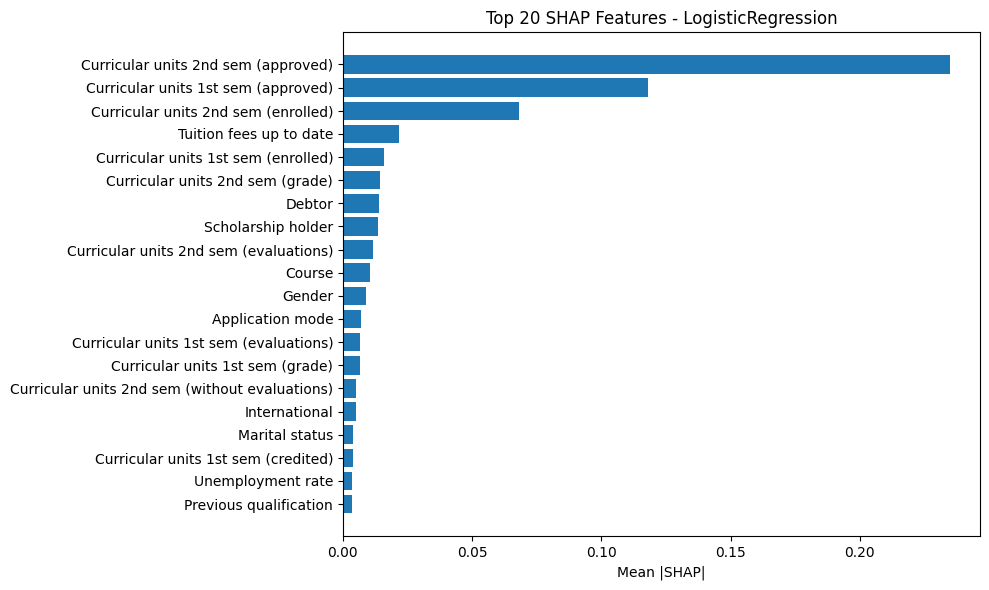

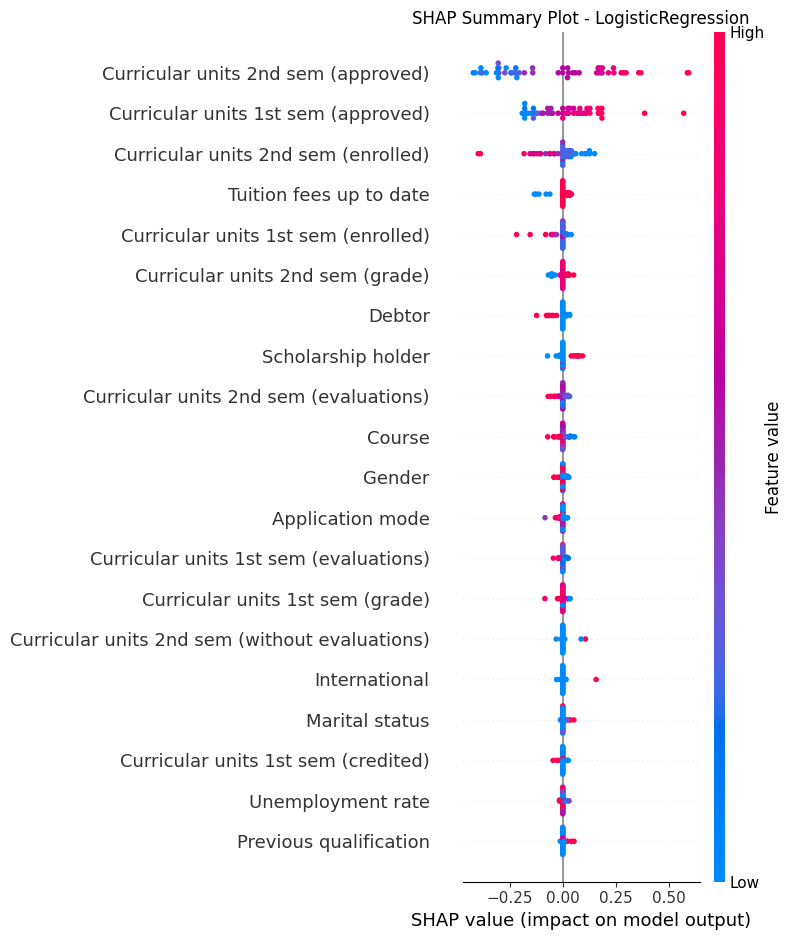

  ✅ SHAP displayed + saved:
     - shap_outputs/LogisticRegression_shap_bar.png
     - shap_outputs/LogisticRegression_shap_summary.png

Running SHAP for: RandomForest


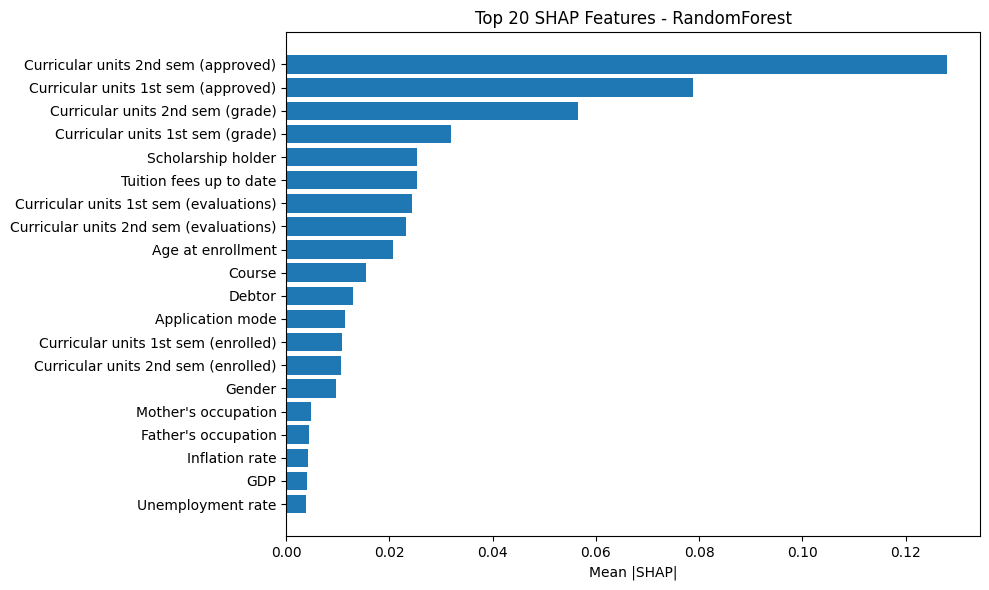

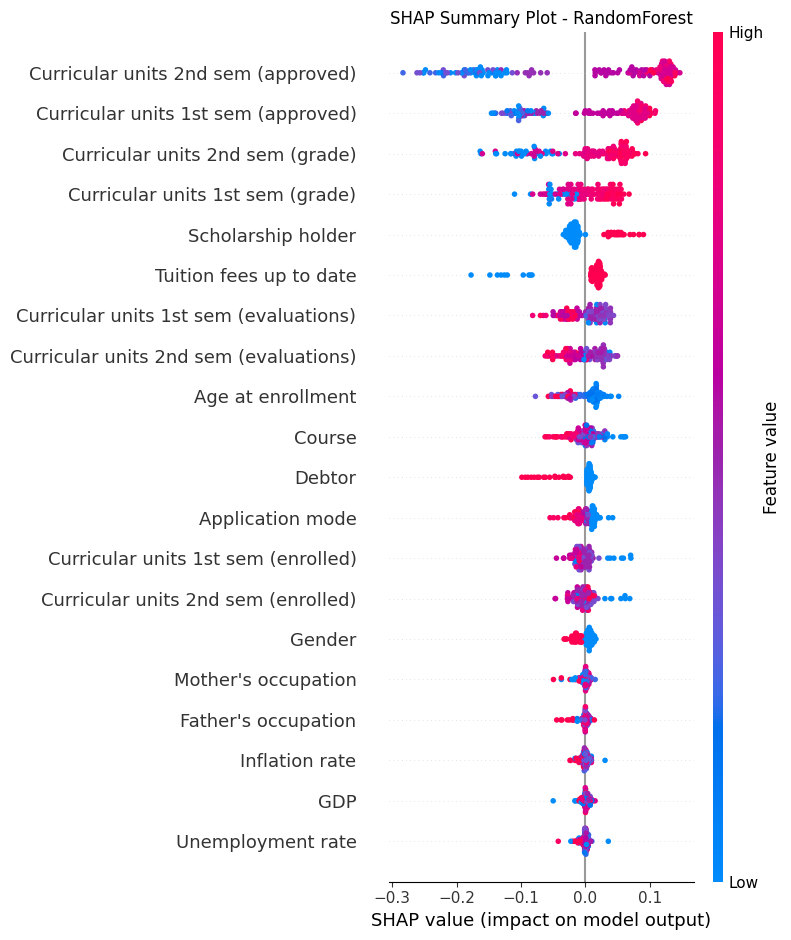

  ✅ SHAP displayed + saved:
     - shap_outputs/RandomForest_shap_bar.png
     - shap_outputs/RandomForest_shap_summary.png

Running SHAP for: HistGB


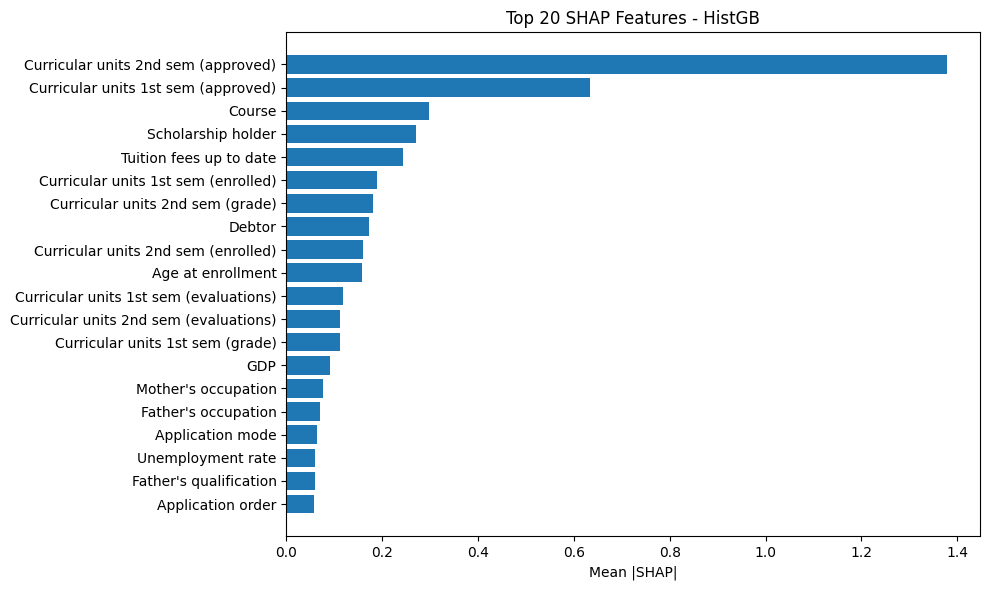

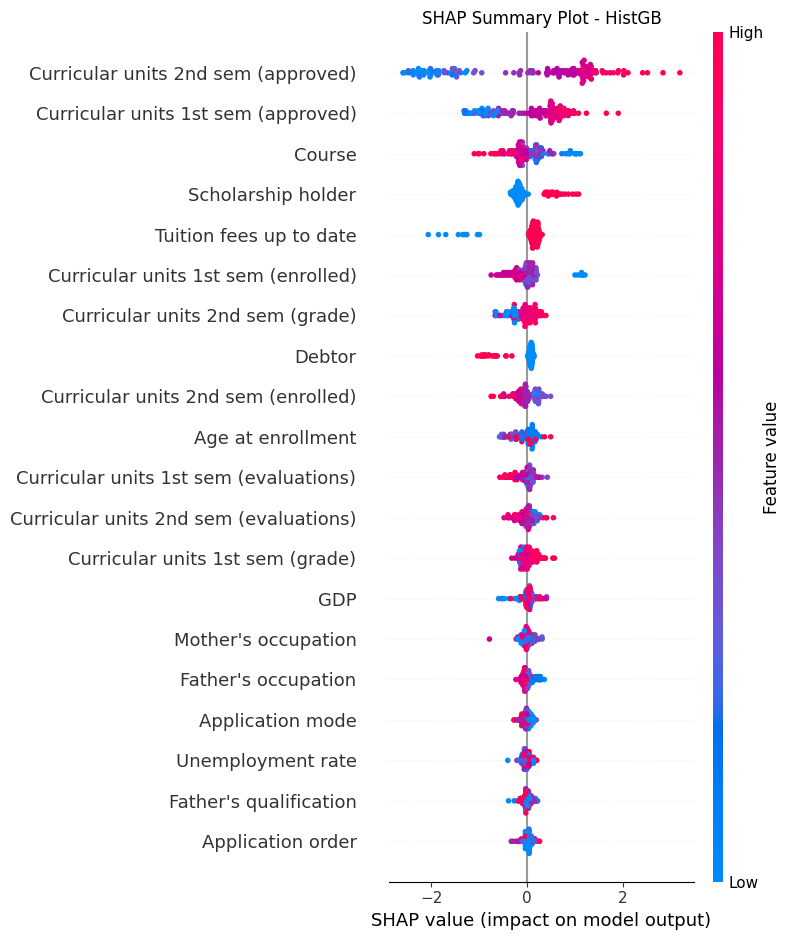

  ✅ SHAP displayed + saved:
     - shap_outputs/HistGB_shap_bar.png
     - shap_outputs/HistGB_shap_summary.png

Running SHAP for: XGBoost


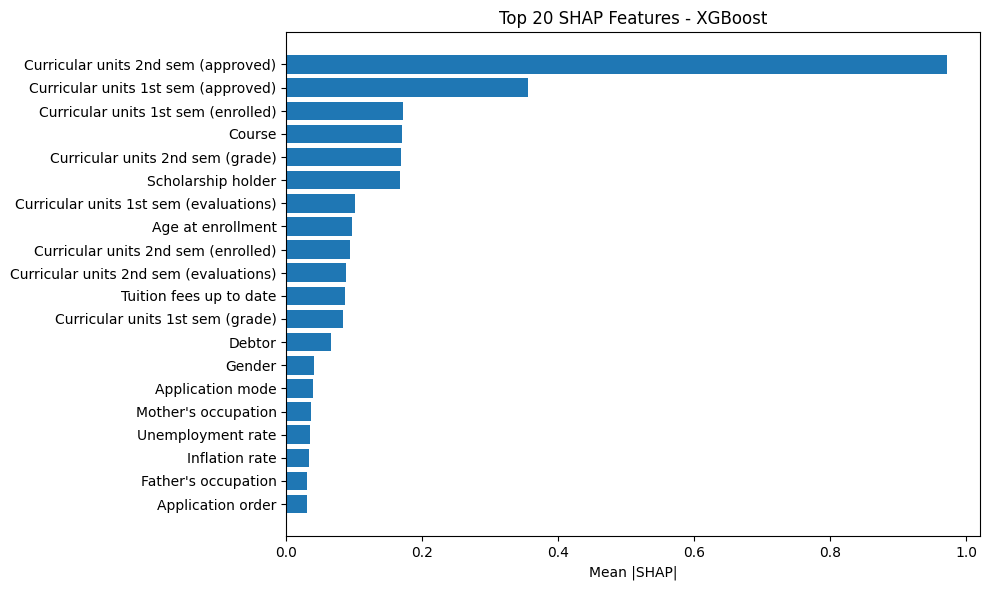

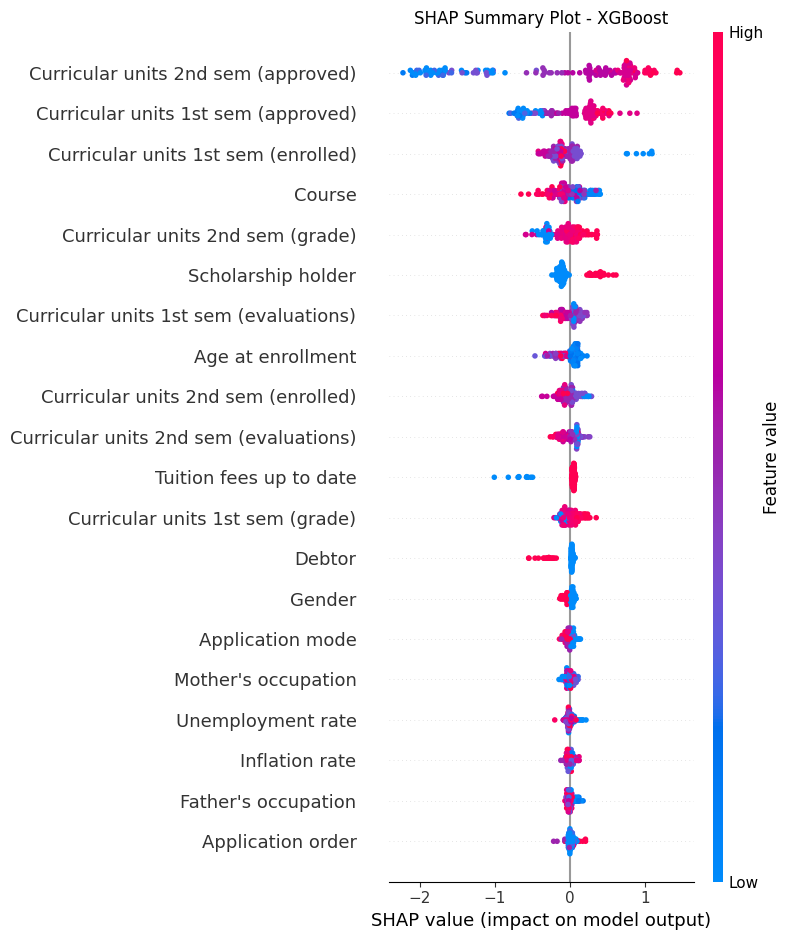

  ✅ SHAP displayed + saved:
     - shap_outputs/XGBoost_shap_bar.png
     - shap_outputs/XGBoost_shap_summary.png

Running SHAP for: LightGBM


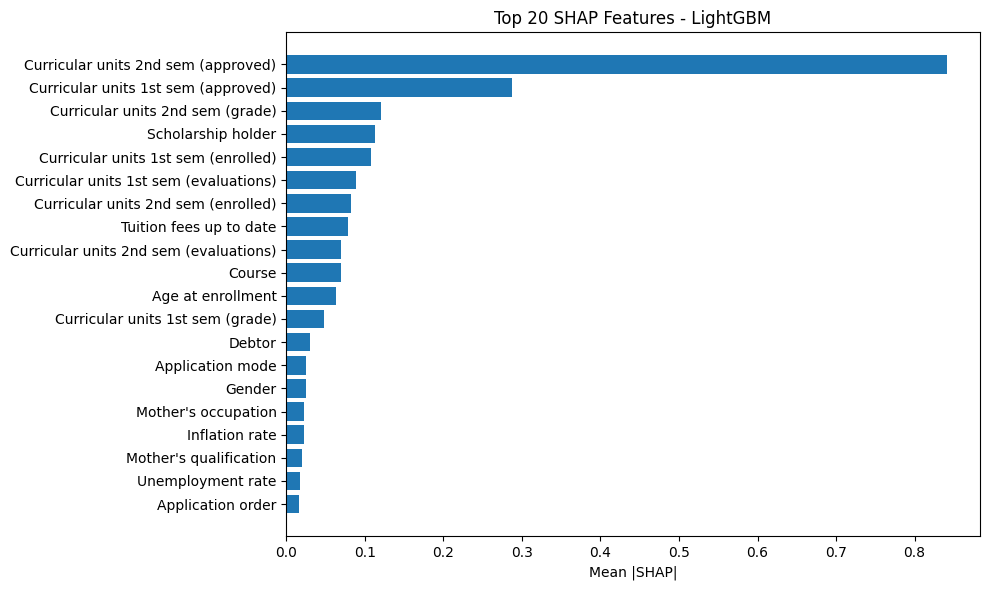

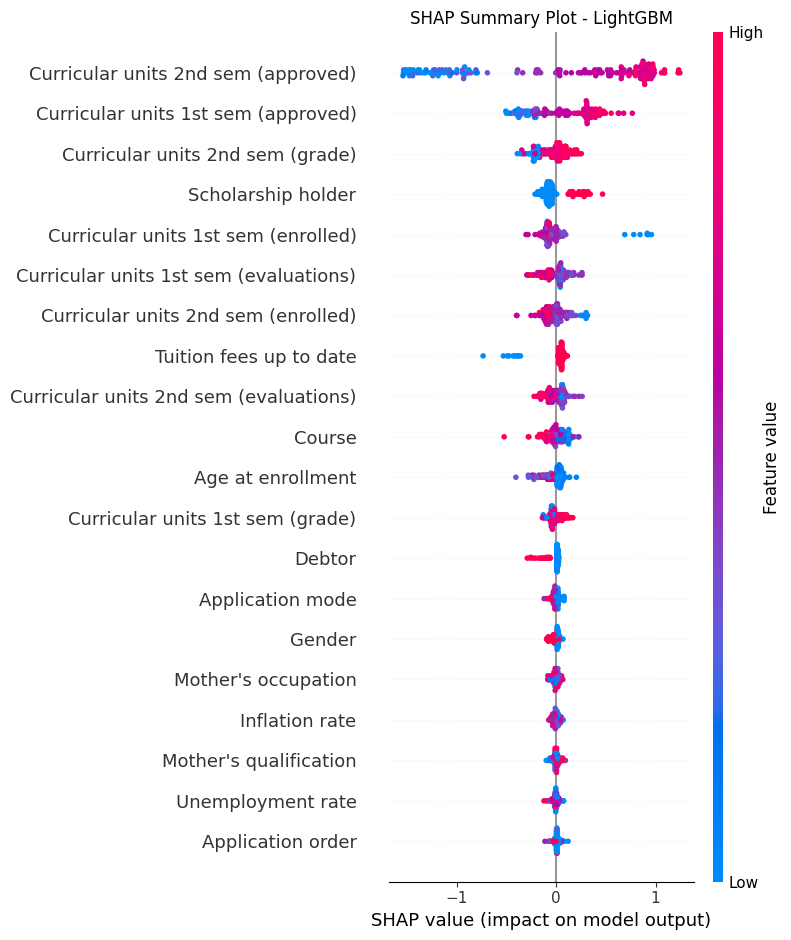

  ✅ SHAP displayed + saved:
     - shap_outputs/LightGBM_shap_bar.png
     - shap_outputs/LightGBM_shap_summary.png

📊 EDUCATIONAL AI READINESS SCORE (per model, 0–5)

Model: LogisticRegression
  Data Quality     : 5.0
  Accuracy         : 3.78
  Interpretability : 1.905
  Scalability      : 4.329
  Fairness         : 0.0
  ✅ Readiness Score: 2.975

Model: RandomForest
  Data Quality     : 5.0
  Accuracy         : 3.881
  Interpretability : 1.211
  Scalability      : 3.649
  Fairness         : 0.0
  ✅ Readiness Score: 2.76

Model: HistGB
  Data Quality     : 5.0
  Accuracy         : 3.825
  Interpretability : 1.156
  Scalability      : 3.756
  Fairness         : 0.0
  ✅ Readiness Score: 2.751

Model: XGBoost
  Data Quality     : 5.0
  Accuracy         : 3.876
  Interpretability : 1.271
  Scalability      : 3.829
  Fairness         : 4.07
  ✅ Readiness Score: 3.611

Model: LightGBM
  Data Quality     : 5.0
  Accuracy         : 3.898
  Interpretability : 1.545
  Scalability      : 3.599


In [ ]:
results_dropout = comprehensive_ml_pipeline(
    dataset_path="retention/dataset.csv",
    target_column="Target",
    task_type="auto",
    fast_mode="auto",
    do_hyperparam_tuning=True,
    compute_shap=True,
    use_tfidf=False
)